In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [4]:
from src.data_loader import load_data
from src.eda_utils import calculate_loss_ratio
from src.visualization import plot_claim_distribution

1. Load Data

In [1]:
import pandas as pd

df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")

df.head()

C:\Users\Lenovo T480s\AppData\Local\Temp\ipykernel_16872\144720666.py:3: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


2. Dataset Overview

In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


## Dataset Overview

The dataset contains historical insurance policy and claim information collected between February 2014 and August 2015. The data includes policy details, customer demographics, vehicle information, geographic attributes, premiums, and claim amounts.

Initial exploration was conducted to understand the structure of the dataset, identify feature types, and evaluate the overall quality of the data before performing further analysis.

3. Missing Values

In [3]:
df.isnull().sum().sort_values(ascending=False)

NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

## Missing Value Assessment

The dataset contains missing values across several variables. Missing data can negatively affect statistical analysis and predictive modeling performance if not handled properly.

Columns with a small proportion of missing values may be handled using imputation techniques such as mean, median, or mode replacement, while columns with excessive missingness may require removal depending on their relevance to the analysis.

4. Insurance Metrics

Loss Ratio = ToatalClaims/TotalPremium

Margin = TotalPremium - TotalClaims

In [4]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

## Loss Ratio Analysis

The Loss Ratio measures the proportion of claims paid relative to premiums collected and serves as a key indicator of portfolio profitability.

A lower loss ratio generally indicates a more profitable insurance portfolio, while higher values suggest elevated financial risk and reduced profitability.

## Margin Analysis

Margin was calculated as the difference between Total Premium and Total Claims. This metric represents the profit contribution generated by each policy.

Positive margins indicate profitable policies, while negative margins suggest that claim costs exceeded the premiums collected.

5. Overall Loss Ratio

In [17]:
overall_loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()

print("Overall Loss Ratio:", overall_loss_ratio)

Overall Loss Ratio: 1.0477452570332206


6. Histograms

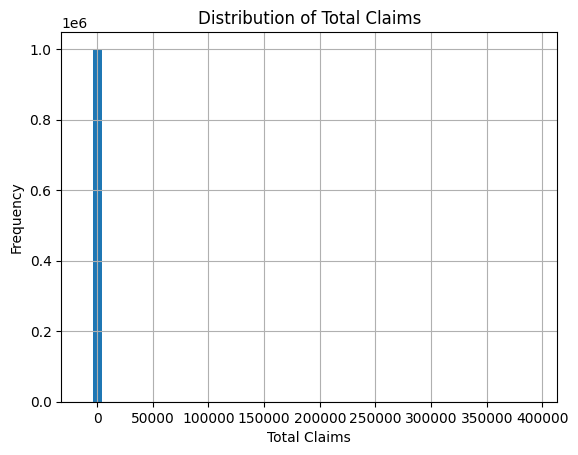

In [18]:
import matplotlib.pyplot as plt

df["TotalClaims"].hist(bins=50)

plt.title("Distribution of Total Claims")

plt.xlabel("Total Claims")

plt.ylabel("Frequency")

plt.show()

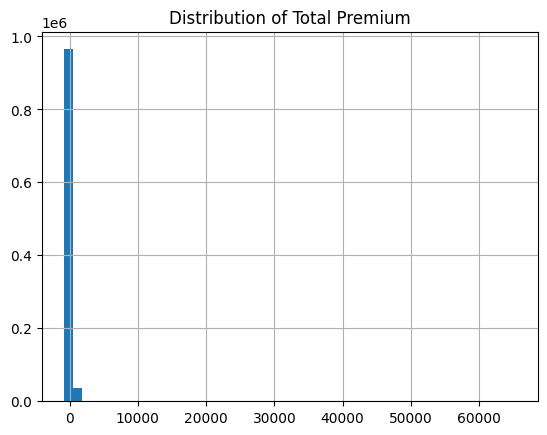

In [19]:
df["TotalPremium"].hist(bins=50)

plt.title("Distribution of Total Premium")

plt.show()

## Distribution of Total Claims

The distribution of Total Claims is highly skewed, with most policies having relatively small claim amounts and a limited number of policies exhibiting extremely high claims.

This pattern is common in insurance datasets and highlights the importance of identifying high-risk outliers during risk assessment and pricing analysis.


## Distribution of Premiums

Premium values vary considerably across policies, reflecting differences in customer risk profiles, vehicle characteristics, and insurance coverage levels.

The presence of skewness indicates that some policyholders pay significantly higher premiums than the majority of customers.

7. Boxplots for Outliers

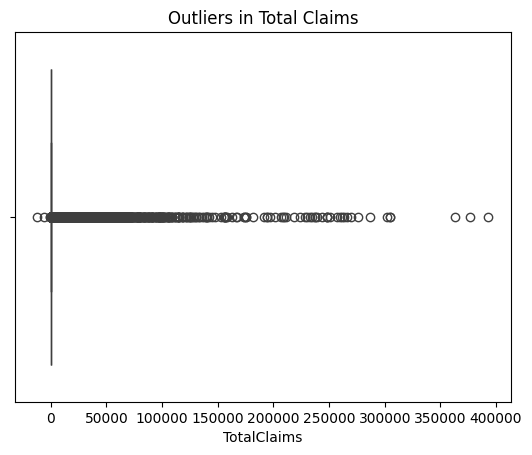

In [20]:
import seaborn as sns

sns.boxplot(x=df["TotalClaims"])

plt.title("Outliers in Total Claims")

plt.show()

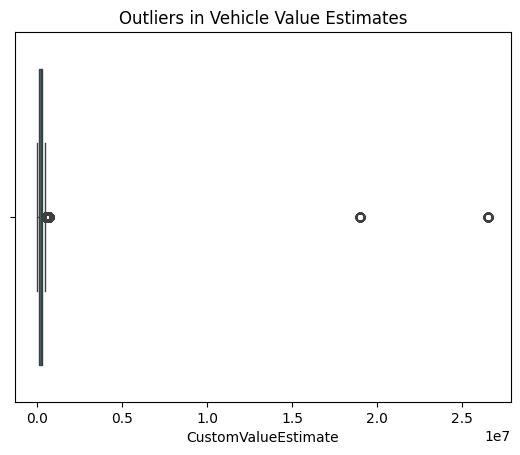

In [21]:
sns.boxplot(x=df["CustomValueEstimate"])

plt.title("Outliers in Vehicle Value Estimates")

plt.show()

## Distribution of Premiums

Premium values vary considerably across policies, reflecting differences in customer risk profiles, vehicle characteristics, and insurance coverage levels.

The presence of skewness indicates that some policyholders pay significantly higher premiums than the majority of customers.

8. Province Risk Analysis

In [22]:
province_loss = df.groupby("Province")["LossRatio"].mean()

province_loss.sort_values(ascending=False)

Province
Eastern Cape          inf
Free State            inf
KwaZulu-Natal         inf
Limpopo               inf
North West            inf
Western Cape          inf
Northern Cape    0.203831
Gauteng               NaN
Mpumalanga            NaN
Name: LossRatio, dtype: float64

c:\Users\Lenovo T480s\Documents\insurance-risk-analytics\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\Lenovo T480s\Documents\insurance-risk-analytics\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


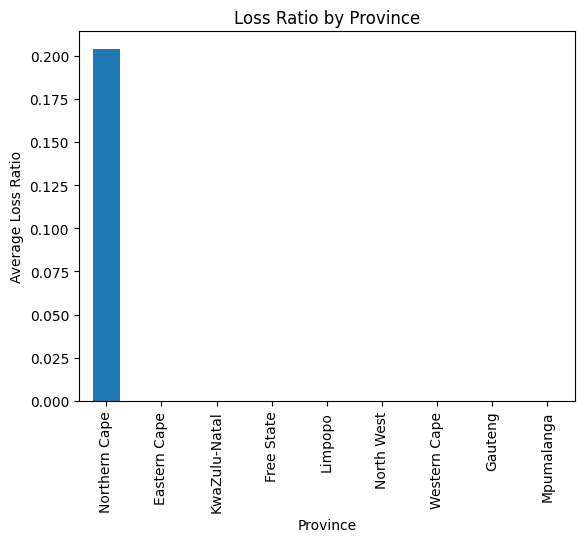

In [23]:
province_loss.sort_values().plot(kind="bar")

plt.title("Loss Ratio by Province")

plt.ylabel("Average Loss Ratio")

plt.show()

## Provincial Risk Analysis

Loss ratios vary across provinces, indicating that geographic location may influence insurance risk levels.

Certain provinces demonstrate consistently higher average claim costs relative to premiums, suggesting that regional factors such as traffic density, road conditions, or crime rates may contribute to increased insurance risk.

9. Gender Risk Analysis

In [24]:
gender_loss = df.groupby("Gender")["LossRatio"].mean()

print(gender_loss)

Gender
Female           inf
Male             inf
Not specified    NaN
Name: LossRatio, dtype: float64


## Gender-Based Risk Analysis

Differences in average loss ratios between genders were examined to evaluate whether claim behavior varies across demographic groups.

The analysis provides insight into whether gender may be associated with differences in insurance risk exposure and claim severity.

In [5]:
import sys
!"{sys.executable}" -m pip install matplotlib seaborn

10. Correlation Heatmap

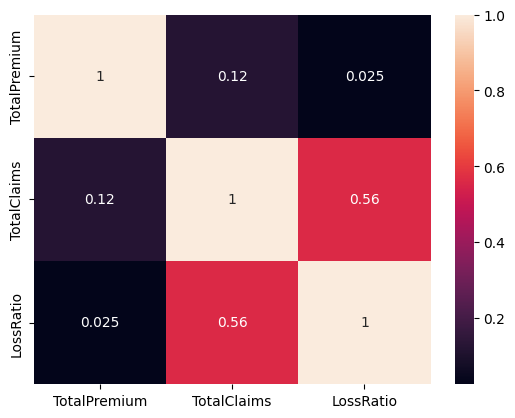

In [9]:
import seaborn as sns

corr = df[["TotalPremium", "TotalClaims", "LossRatio"]].corr()

sns.heatmap(corr, annot=True)
plt.show()

  ## Correlation Analysis

Correlation analysis was conducted to evaluate relationships among key financial variables including premiums, claims, margins, and loss ratios.

The heatmap highlights both positive and negative relationships between variables, helping identify factors that may influence insurance profitability and risk exposure.

In [ ]:
5. Temporal Trends

In [10]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

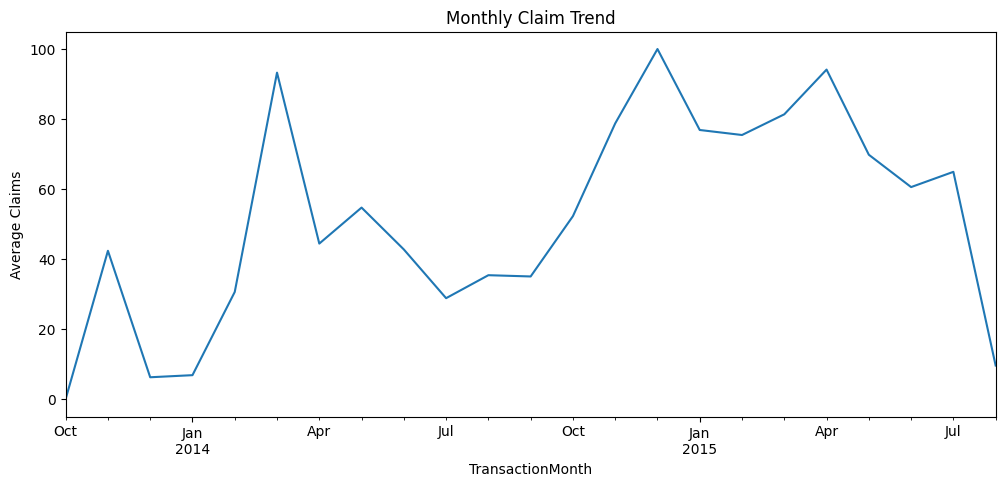

In [11]:
monthly_claims = df.groupby("TransactionMonth")["TotalClaims"].mean()

monthly_claims.plot(figsize=(12,5))

plt.title("Monthly Claim Trend")

plt.ylabel("Average Claims")

plt.show()

   ## Temporal Trend Analysis

Monthly claim trends were analyzed to identify potential seasonal patterns and changes in claim behavior over time.

Variations in claim frequency or severity across months may reflect changing driving conditions, economic factors, or operational trends within the insurance portfolio.

6. Vehicle Make/Model Analysis

In [13]:
vehicle_claims = df.groupby("Model")["TotalClaims"].mean()

vehicle_claims.sort_values(ascending=False).head(10)

Model
L/CRUISER FJ 4.0 V6 CRUISER    5340.970273
H-1 2.5 CRDI WAGON A/T         4118.181043
DUCATO 2.3 JTD VETRATO         1014.681021
POLO VIVO 1.6 5Dr               827.558882
C180 BE COUPE                   743.459027
SPRINTER 312D F/C P/V           664.540138
ERTIGA 1.4 GA                   631.774519
YARIS T1 3Dr                    618.719846
A4 1.8T S AVANT MULTITRONIC     480.282859
POLO 1.6 COMFORTLINE            431.842105
Name: TotalClaims, dtype: float64

In [14]:
vehicle_claims.sort_values().head(10)

Model
C200K CLASSIC A/T           -0.250832
VENTURE 2400D 6+4 New        0.000000
50C15V15 F/C P/V             0.000000
0305 M BAR B/S CCL           0.000000
YARIS ZEN3 ACS               0.000000
YARIS ZEN3                   0.000000
YARIS 1.3 5Dr                0.000000
ACCENT 1.5 CSi               0.000000
A5 SPRTBACK 2.0 TDI MULTI    0.000000
A4 3.0 TDI QUATTRO (B7)      0.000000
Name: TotalClaims, dtype: float64

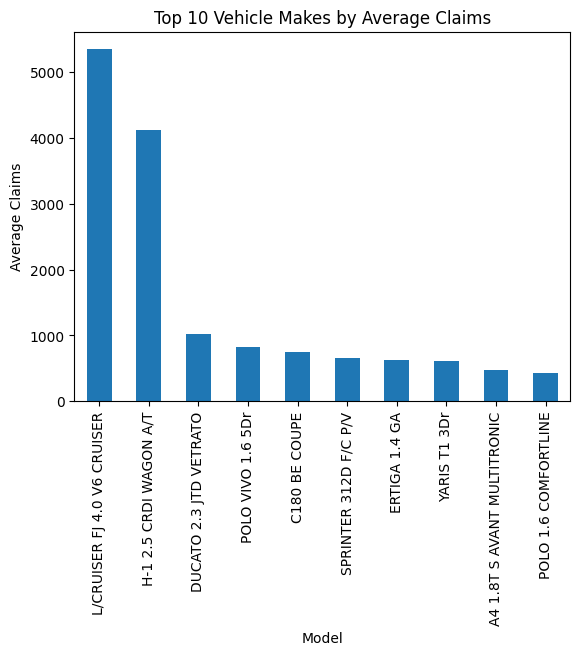

In [15]:
vehicle_claims.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Vehicle Makes by Average Claims")

plt.ylabel("Average Claims")

plt.show()

## Vehicle Make and Claim Analysis

Average claim amounts were compared across vehicle manufacturers to identify high-risk and low-risk vehicle categories.

Certain vehicle makes exhibit substantially higher claim costs, which may be influenced by repair expenses, theft rates, accident frequency, or driver behavior associated with those vehicles.

Overall EDA Conclusion Markdown

## Exploratory Data Analysis Conclusion

The exploratory data analysis provided valuable insights into the structure, quality, and risk characteristics of the insurance dataset.

Key findings include significant variability in claims and premiums, the presence of outliers, geographic differences in loss ratios, and temporal patterns in claim behavior. These insights establish a strong foundation for subsequent hypothesis testing and predictive modeling tasks.

Geographic Trends

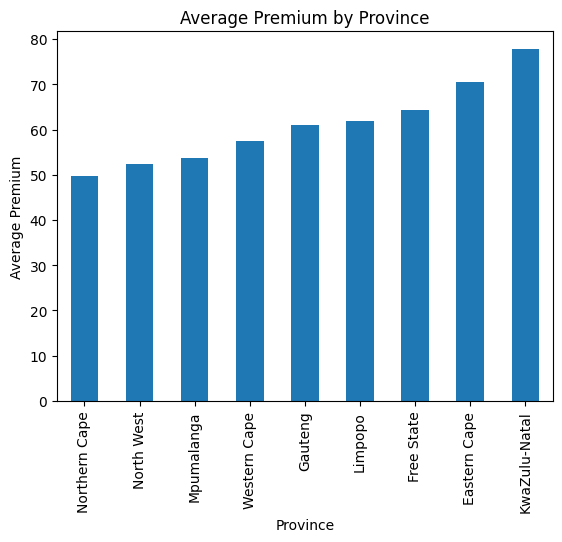

In [16]:
province_premium = df.groupby("Province")["TotalPremium"].mean()

province_premium.sort_values().plot(kind="bar")

plt.title("Average Premium by Province")

plt.ylabel("Average Premium")

plt.show()